<a href="https://colab.research.google.com/github/NathalieKa/Python101/blob/main/LineareRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<figure>
  <IMG SRC="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d5/Fachhochschule_Südwestfalen_20xx_logo.svg/320px-Fachhochschule_Südwestfalen_20xx_logo.svg.png" WIDTH=250 ALIGN="right">
</figure>

# Einführung Machine Learning
### Sommersemester 2026
Prof. Dr. Heiner Giefers

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

Was ist lineare Regression?

Lineare Regression ist ein Verfahren, mit dem man den Zusammenhang zwischen Variablen durch eine Gerade beschreibt. Der einfachste Fall: Du willst eine Variable (die *abhängige* Variable, meist yy
y genannt) durch **eine einzige** andere Variable (die *unabhängige* Variable xx
x) vorhersagen. Dieser Spezialfall heißt:


einfache Lineare Regression (ELR) oder
univariate Lineare Regression

## Lineare Regression

Der einfachste Fall der Lineraen Regression ist die Vorhersage einer (*abhängigen*) Variablen durch **eine** *unabhängige* Variable.
Dieser Spezialfall wird daher auch *einfache Lineare Regression* (ELR) oder *univariate Lineare Regression* genannt.

Wir wollen die ELR an einem einfachen Datensatz erproben.
Dazu generieren wir uns $N=30$ Datenpunkte im Bereich $x\in[0,10]$.
Die $y$-Werte sollen grob entlang einer geraden liegen.
Wir wählen für die gerade eine Steigung von $2$ und den Achsenabschnitt $-5$.

Natürlich sollen die Punkte nicht alle **auf** dieser Geraden liegen.
Daher fügen wir noch einen kleinen *Störfaktor* ein.
Wir addieren zu jedem $y$-Wert einen Wert aus dem Bereich $[-1,1]$.

**Für jeden x-Wert berechnen wir den y-Wert mit der Formel :**

        y = 2x - 5


*Das Problem: In der echten Welt liegen Messdaten nie perfekt auf einer Geraden. Stell dir vor:*


Du misst die Größe und das Gewicht von Menschen → der Zusammenhang ist ungefähr linear, aber nicht perfekt.
Du misst Temperatur und Stromverbrauch → ähnlich.


Wenn unser Datensatz also realistisch sein soll, müssen die Punkte leicht streuen.

**Lösung: Zu jedem berechneten y-Wert addieren wir eine kleine Zufallszahl zwischen −1 und +1**




---

Das n in randn steht für normal (Normalverteilung).

Was bedeutet "normalverteilt"?np.random.randn(N) liefert Zahlen aus der
berühmten Glockenkurve (auch Gaußverteilung):

Mittelwert: 0 (die Zahlen liegen meistens nahe 0)
Standardabweichung: 1

Das 2 * macht das Rauschen also doppelt so stark – die Zahlen streuen weiter weg von 0.




---


Die Mitte ist immer 0
np.random.randn(N) ist so programmiert, dass die Werte immer um 0 herum schwanken. Das ist die "Zielscheiben-Mitte" – sie verschiebt sich nie.

* np.random.randn(N) → Mitte bei 0, Streuung ±1

* 2 * np.random.randn(N) → Mitte bei 0, Streuung ±2

* 100 * np.random.randn(N) → Mitte bei 0, Streuung ±100



---



Je größer x desto größer wird auch y.

y = mx - b

Das Model kennt nur x die Daten punkte und y.

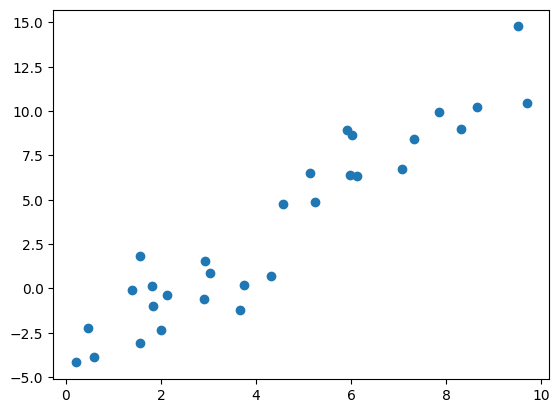

In [2]:
np.random.seed(42) #Seed: Immer dieselben Zufallszahlen
N = 30 #Datenpunkte
x = 10 * np.random.rand(N) #0.37*10 = 3.7, 30 mal (Werte von 1 bis 10)
y = 2 * x - 5 + 2*np.random.randn(N)
plt.scatter(x, y);#Zeichnet ein streudiagramm
plt.show() # x=1-10 , y=Zufallwerte

Wir können nun die *Scikit-Learn* Klasse `LinearRegression` verwenden, um ein ELR Modell für den Datensatz aufzustellen.
Mit der `fit`-Methode passen wir das Modell an den Datensatz an.

*Hinweis:* Die `fit`-MEthode erwartet ein 2-dimensionales Feld als ersten Parameter. Unser `x` ist aber ein eindimensionales Array. Wir ändern daher mit der `reshape`-Methode die Dimension von `x` vor dem Aufruf von `fit` um.

Erinnerung: Wir haben 30 verrauschte Datenpunkte erzeugt, die ungefähr auf der Geraden y=2x−5y = 2x - 5
y=2x−5 liegen. Jetzt soll der Computer aus den Punkten die Gerade wiederfinden – ohne zu wissen, dass es 2 und -5 sind.

In [3]:
from sklearn.linear_model import LinearRegression
model = LinearRegression() #leeres model

#Eine Tabelle aus 1 Spalte - die Anzahl der Zeilen ergibt sich automatisch (-1)
x = x.reshape((-1,1)) # Vorher (eindimensional, eine "Zeile" mit 30 Zahlen), Nachher (zweidimensional, 30 Zeilen mit je 1 Zahl)
model.fit(x, y) # hier passt das Model die Werte an und sucht die bestmögliche Gerade durch die Punkte, er findet m und b.

print("Steigung:       ", model.coef_[0]) # m = steigung
print("Achsenabschnitt:", model.intercept_) # b = Achsenabschnitt

#   Vergleich
# m1 = 2, m2 = 1.721
# b1 = -5 , b2 = -4,14



Steigung:        1.7213842056621573
Achsenabschnitt: -4.142057444197555


Wir können nun die Modellfunktion plotten indem wir zunächst einige neue Datenpunkte erzeugen (`xplot`) und für diese Punkte den $y$-Wert über die `predict`-Methode schätzen.

Wir sehen, dass die Gerade die blauen Datenpukte unseres Trainingsdatensatzes sehr gut generalisiert.

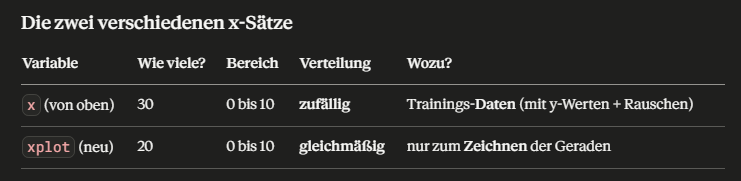

**Warum nicht einfach x benutzen?**

Aber: plt.plot zeichnet die Punkte in der Reihenfolge, in der sie im Array stehen, und verbindet sie mit Strichen.
Die Original-x-Werte sind aber durcheinander:

      x = [3.7, 9.5, 7.3, 5.9, 1.5, ...]


Die Lösung: linspace
linspace liefert x-Werte in der richtigen Reihenfolge:

     xplot = [0, 0.53, 1.05, 1.58, ..., 9.47, 10]

Klein → groß, der Reihe nach. Werden diese verbunden, kommt eine saubere Linie von links nach rechts heraus.

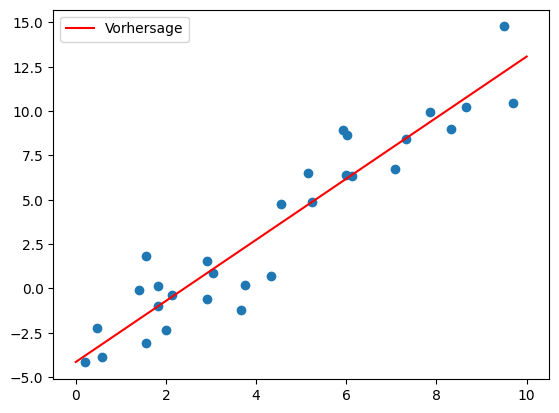

In [4]:
xplot = np.linspace(0, 10, 20).reshape((-1,1)) #erzeugt 20 gleichmäßig verteilte x Werte zwischen 0 und 10 (nicht zufällig). Danach wird wieder eine Tabelle erstellt
yplot = model.predict(xplot) #model nutzt das gelernte

plt.scatter(x, y) # Zeichnet die 30 Original-Datenpunkte als Streudiagramm !!!
plt.plot(xplot, yplot, c='r', label="Vorhersage") # Zeichnet eine rote Linie durch die 20 berechneten Punkte
plt.legend() # zeigt die kleine Erklärbox im Diagramm an ("Vorhersage" mit rotem Linienstück)
plt.show()

**Was hat das Modell vorher gelernt?**

Im Schritt davor (model.fit(x, y)) hat das Modell aus den 30 Datenpunkten eine Gerade gelernt

        1,72 * x- 4,14

Diese Formel steckt jetzt im Modell drin. Es kennt also Steigung (1,72) und Achsenabschnitt (-4,14).


Hier "benutzt" das Modell sein Gelerntes! 🧠

predict heißt "vorhersagen".

Das Modell nimmt jeden x-Wert aus xplot und berechnet den dazugehörigen y-Wert mit der gelernten Geradengleichung.

Der ``LinearRegression`` Schätzer kann nicht nur auf univariate Probleme angewendet werden, sondern er funktioniert auch für mehrere unabhängige Variable.
Die Modellfunktion einer allgemeinen (*multivariaten*) lineren Regression lautet:
$$
\hat{y} = a_0 + a_1 x_1 + a_2 x_2 + \cdots + a_n x_n
$$

Dabei sind die $x_i$ die einzelnen unabhängigen Variablen, die Werte $a_i$ sind die zu trainierenden Modellparameter.
Der Parameter $a_0$, den wir beim univariaten Modell *Achsenabschnitt* genannt haben, heißt auch *Bias*-Parameter.
Es ist der einzige Parameter, der unabhängig von den Variablen ins Modell eingeht.

$\hat{y}$ ist der geschätzte Wert der Zielvariablen für den Vektor $\textbf{x}$.
Für unsere Trainingsdaten kennen wir den jeweiligen exakten Wert $y$.
Über einen Vergleich von $\hat{y}$ und $y$ kann man feststellen, wie *gut* die Schaätzung der Modellfunktion ist.

Jetzt verwenden wir mehrere Variablen und die Formel erweitert sich.

* y-dach = Vorhersage
* y = der echte gemessene Wert (tatsächlicger vkpreis)
* x = Eingangsvariablen
* a0 = Achsenabschnitt
* a1..ax = Gewichte

Der wichtige Sprung: Statt einer Eingabe können wir jetzt viele Eingaben gleichzeitig benutzen. Das Modell findet automatisch heraus, wie wichtig jede einzelne Variable ist (durch die Gewichte a1​,a2​,…).


Das ist enorm mächtig: In der Praxis hat man fast nie nur eine Eingabevariable, sondern oft dutzende oder hunderte.

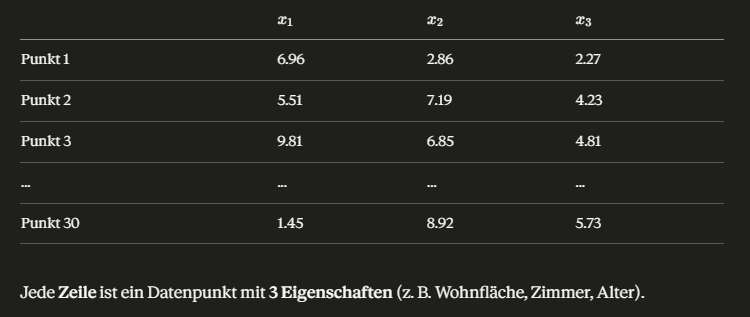

Zeile 4: noise = np.random.normal(0, 0.5, (N, 3))
Erzeugt Rauschen für die X-Werte (also die Eingaben).
np.random.normal(0, 0.5, (N, 3)) heißt:

Mittelwert 0

Standardabweichung 0.5

Form: 30 Zeilen, 3 Spalten

Das ist äquivalent zu 0.5 * np.random.randn(N, 3). Es liefert wieder eine 30×3-Tabelle, aber mit kleinen Werten um 0 herum (meistens zwischen −1 und +1).

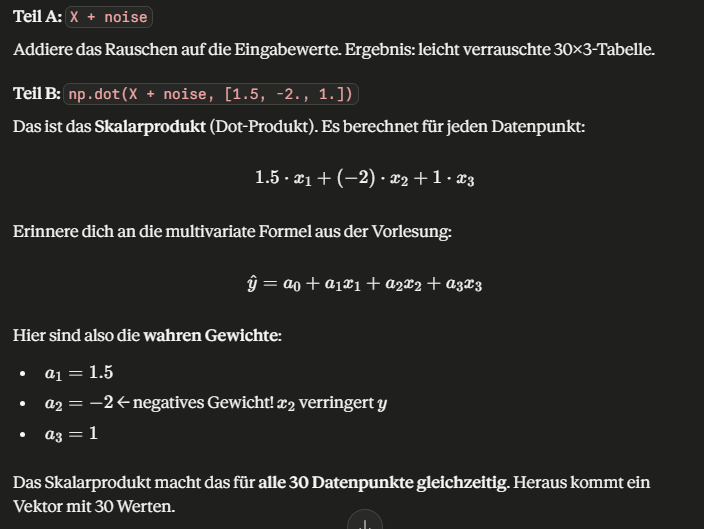

Teil D: + 0.5 * np.random.randn(N)

Zusätzliches Rauschen auf den y-Werten (Standardabweichung 0.5). Damit die Punkte nicht perfekt auf der "Hyperebene" liegen.

Es werden die Eingabe werte X selbst gerauscht und am ende die Y Wert die Ergebnisse.

Warum? -> Beide Werte sind nicht immer zu 100% korrekt.

Beispiel: X = Vielleicht daneben geschätzt



---


**Sinn?** (WICHTIG)

Das Modell bekommt aus der Formel nur xi und y das Ergebnis.

[1.5, -2., 1.] sind die richtigen Werte und das Ergebnis y.

Das Modell versucht, diese 4 Zahlen zu lernen.

So läuft das Spiel ab:

1. Du gibst dem Modell nur X und y.
2. Das Modell sieht: „Okay, hier sind 30 Beispiele. Bei jedem Beispiel habe ich 3 Eingabewerte und 1 Ausgabewert."
3. Das Modell fragt sich: „Mit welchen 4 Zahlen muss ich die Eingaben multiplizieren und addieren, damit am Ende die richtigen Ausgabewerte rauskommen?"
4. Es probiert herum und findet schließlich: „Aha, ich glaube die 4 Zahlen sind ungefähr 0.5, 1.5, -2, 1."


Es sieht nur Zahlen. Es muss die 4 Gewichte selbst erraten, indem es die Daten analysiert.



---



In [5]:
np.random.seed(123) #reproduzierbare Zufallszahlen
N = 30 # Datenpunkte
X = 10 * np.random.rand(N, 3) # erzeugt eine Tabelle mit 30 Zeilen und 3 Spalten – also 30×3=90 zwischen 0 und 1. (*10 = 0-10 Zahlen)
noise = np.random.normal(0, 0.5, (N,3)) #Erzeugt Rauschen für die X-Werte
y = 0.5 + np.dot(X+noise, [1.5, -2., 1.]) + 0.5*np.random.randn(N) # addiere x mit rauschen / 0.5 = a0 / 1.5, -2, 1 = Gewichte

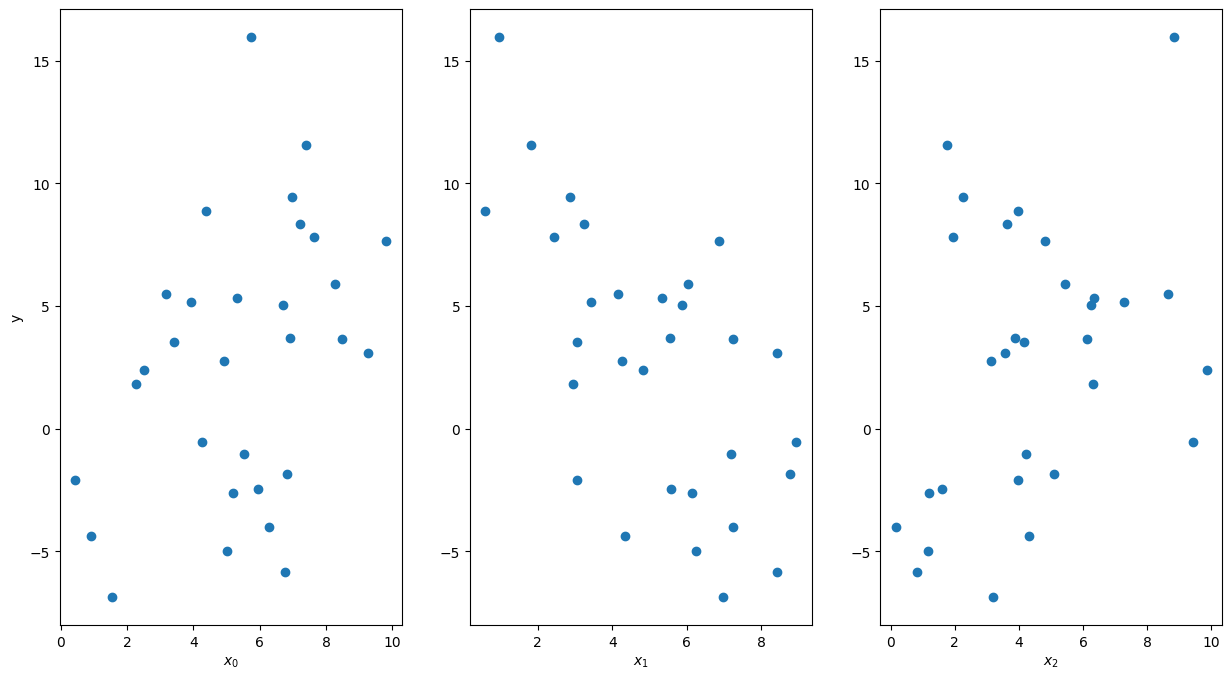

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15,8)) # Erzeugt eine Figur mit 3 Diagrammen nebeneinander. 1 Zeile, 3 Spalten → drei Diagramme in einer Reihe
#axs ist eine Liste mit 3 Diagramm-Objekten: axs[0], axs[1], axs[2]
axs[0].scatter(X[:,0], y) # Alle Zeilen, Spalte 0 -> x1
axs[1].scatter(X[:,1], y) #Spalte 1 -> x2
axs[2].scatter(X[:,2], y) #Spalte 2 -> x3
axs[0].set_ylabel('y') # y-Achse beschriften
axs[0].set_xlabel(r'$x_0$')
axs[1].set_xlabel(r'$x_1$')
axs[2].set_xlabel(r'$x_2$')
plt.show() #Die Diagramme sind einfach zum Anschauen der Daten, bevor das Modell überhaupt loslegt.

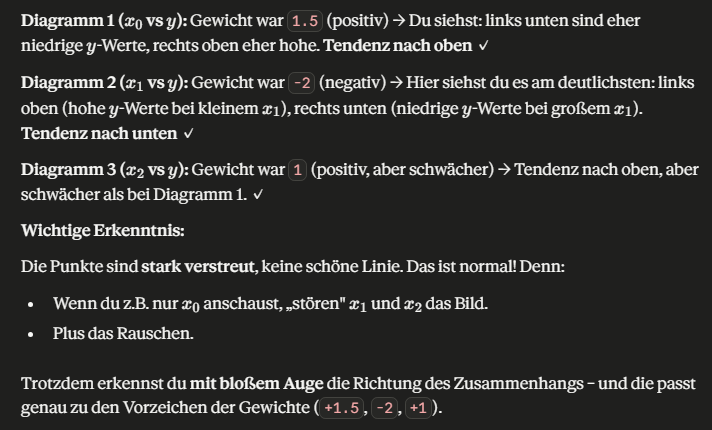

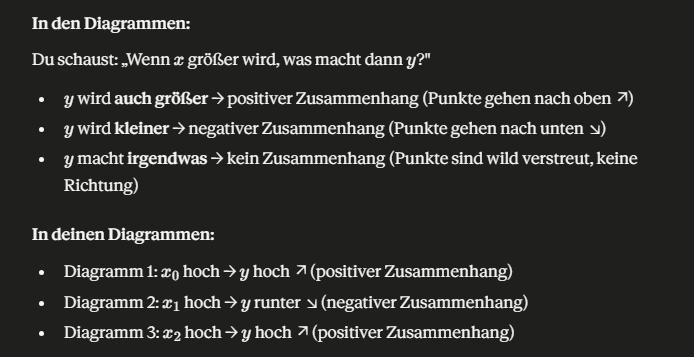

**Aufgabe:** Trainieren Sie ein `LinearRegression` Modell mit dem Datensatz `X` und geben Sie die gelerneten Modellparameter $a_0$ bis $a_3$ aus.

In [7]:
model = LinearRegression()
model.fit(X,y)
#raise NotImplementedError()

LinearRegression()

### California Housing

Im folgenden Beispiel verwenden wir einen Datensatz zu Immobilienpreisen in den USA für die Demonstration von Regressions-Aufgaben.
Die Daten wurden 1990 bei der US-Volkszählung gesammelt und beschreiben Eigenschaften der Wohnverhältnisse in Bezirken des Bundesstaats Kalifornien.
Die Zielvariable ist der Median des Hauswertes, angegeben in Hunderttausend Dollar.

In [8]:
import numpy as np #Rechnen mit Zahlen/Arrays
from sklearn.linear_model import LinearRegression #Modell
import pandas as pd #Tabellen anzeigen und bearbeiten
from sklearn.datasets import fetch_california_housing #der Datensatz mit den Häuserpreisen

#print(dataset.DESCR)
dataset = fetch_california_housing() #lädt den Datensatz herunter
df = pd.DataFrame(dataset.data, columns=dataset.feature_names) # packt die Daten in eine Tabelle
df.head() # zeigt die ersten 5 Zeilen, damit du siehst, wie die Daten aussehen

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Der Datensatz enthält folgende Merkmale:
- **MedInc:** Median des Einkommens im Bezirk
- **HouseAge:** Median des Hausalters im Bezirk
- **AveRooms:** Durchschnittliche Anzahl der Zimmer pro Haushalt
- **AveBedrms:** Durchschnittliche Anzahl der Schlafzimmer pro Haushalt
- **Population:** Anzahl Bewohner*innen im Bezirk
- **AveOccup:** Durchschnittliche Anzahl der Haushaltsmitglieder
- **Latitude:** Breitengrad des Bezirks
- **Longitude:** Längengrad des Bezirks

Die Zielvariable `target` ist der Preis der jeweiligen Häuser in Hunderttausend US-Dollar

In [9]:
preise = dataset.target
print(f"Der Wert der Häuser reicht von {int(np.min(preise)*100)} bis {int(np.max(preise)*100)} Tausend $")
print(f"Im Mittel kosten die Häuser {int(np.mean(preise)*100)} Tausend $")

Der Wert der Häuser reicht von 14 bis 500 Tausend $
Im Mittel kosten die Häuser 206 Tausend $


* np.min(preise) → der billigste Preis
* np.max(preise) → der teuerste Preis
* np.mean(preise) → der Durchschnittspreis

**Aufgabe:** In der folgenden Code-Zelle teilen wir den Datensatz auf, in einen Trainings- und in einen Testdatensatz.
Verwenden Sie die Trainingsdaten, um ein lineares Regressionsmodell zu trainieren.
Berechnen Sie damit eine Schätzung `y_vorhersage` für die Testdaten.
Danach berechnen wird den *mittleren absoluten Fehler* und überprüfen damit, wie gut unser Modell die Preise der Häuser schätzen kann.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error

X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size=0.3, random_state=42) # 70% Trainingsdaten 30% Testdaten

model = LinearRegression()
model.fit(X_train, y_train)  #erhält die x-werte und y-werte. Das Modell sucht a0...

y_vorhersage = model.predict(X_test) #Das Modell erhält die Testdaten zum vorhersagen. Das Modell setzt die gelernte a werte in die Formel ein


#raise NotImplementedError()

# Mean Average Error per Hand ausrechnen
mittlerer_fehler = np.sum(np.abs(y_vorhersage-y_test))/len(y_vorhersage)

print(f"Der mittlere Fehler der Vorhersage liegt bei {int(mittlerer_fehler*100)} Tausend $")
err_percent = mean_absolute_percentage_error(y_test, y_vorhersage)
print(f"Damit liegen wir im Mittel ca. {int(err_percent*100)}% daneben")

Der mittlere Fehler der Vorhersage liegt bei 52 Tausend $
Damit liegen wir im Mittel ca. 31% daneben


**Aufgabe:** Berechnen Sie das Bestimmtheitsmaß \( $R^2$ \) für die Vorhersagen auf den Testdaten.

- $R^2$ gibt an, welcher Anteil der Varianz der Zielvariable durch das Modell erklärt wird.
- Verwenden Sie dafür die Funktion `r2_score` aus `sklearn.metrics`.
- Ein Wert nahe 1 bedeutet eine sehr gute Modellanpassung.

Geben Sie das Ergebnis mit zwei Nachkommastellen aus.

In [11]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_vorhersage) # y test = echten Preise , y_vorhersage

#raise NotImplementedError()

print(f"Das Bestimmtheitsmaß R² beträgt {r2:.2f}")

Das Bestimmtheitsmaß R² beträgt 0.60


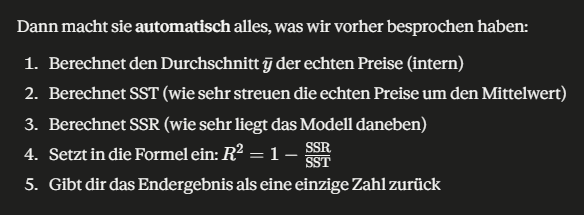

## Quellen:
[1] Jake VanderPlas, [*Python Data Science Handbook*](https://jakevdp.github.io/PythonDataScienceHandbook), O'Reilly, 2016.\
[2] Wolf Riepl, [*Machine Learning mit R und caret: GBM optimieren (Gradient Boosting Machine)*](https://statistik-dresden.de/archives/14967), Artikel auf https://statistik-dresden.de,  Veröffentlicht am 23.01.2018 (zugegriffen am 27.04.2021)